<h2>Data Analytics- notebook, empty template</h2>

**NOTE:** All AI usage rules etc. apply to data analytics notebooks too. Always mention if generative AI has been used, and how you can be sure the solution is correct!

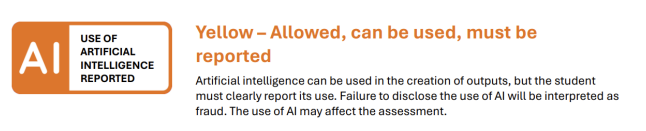

<h4><b>Dataset name / short description:</b></h4>

**World Happiness Report 2021**

This dataset contains happiness-related information for 153 countries.  
The main variable is **Ladder score**, which represents the country's life evaluation/happiness score.

The dataset also contains information about:
- GDP per capita
- Social support
- Healthy life expectancy
- Freedom to make life choices
- Generosity
- Perceptions of corruption
- Region

<h4><b>Data source (url):</b></h4>

https://www.kaggle.com/datasets/anamvillalpando/world-happiness-ranking?resource=download&select=Happiness.csv

<h4><b>Data format:</b></h4>

The data is stored in a **CSV (Comma-Separated Values)** file called `Happiness.csv`.

<h4><b>Data description, features and limitations:</b></h4>

- **Used the help of the AI for clearly mention my findings** 
### Important features

- **Country name** – name of the country.
- **Regional indicator** – geographical region.
- **Ladder score** – overall happiness/life evaluation score.
- **Logged GDP per capita** – economic situation.
- **Social support** – support available from family, friends, or community.
- **Healthy life expectancy** – expected healthy years of life.
- **Freedom to make life choices** – perceived freedom.
- **Generosity** – generosity of people.
- **Perceptions of corruption** – perception of corruption.

### Limitations

- The dataset represents one report/year, so it does not show changes over many years.
- The data is at country level, so it cannot describe every individual person.
- Correlation shows a relationship, but it does not prove that one variable causes another.
- Some variables are related to the calculation of the happiness score itself, so they should not be interpreted as independent causes.

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Happiness.csv')
df.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.8087,0.031156,7.869766,7.747634,10.639267,0.954330,71.900825,0.949172,-0.059482,0.195445,1.972317,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857,2.762835
1,Denmark,Western Europe,7.6456,0.033492,7.711245,7.579955,10.774001,0.955991,72.402504,0.951444,0.066202,0.168489,1.972317,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741
2,Switzerland,Western Europe,7.5599,0.035014,7.628528,7.491272,10.979933,0.942847,74.102448,0.921337,0.105911,0.303728,1.972317,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267
3,Iceland,Western Europe,7.5045,0.059616,7.621347,7.387653,10.772559,0.974670,73.000000,0.948892,0.246944,0.711710,1.972317,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688
4,Norway,Western Europe,7.4880,0.034837,7.556281,7.419719,11.087804,0.952487,73.200783,0.955750,0.134533,0.263218,1.972317,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266


In [2]:
# Check the missing values and duplicate values
print(df.isna().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Country name                                  0
Regional indicator                            0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       0
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         0
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           0
dtype: int64
Duplicate rows: 0


<h3><b>Code: Data clean-up procedure</b></h3>

The dataset has no missing values and no duplicate rows, so no rows need to be removed.
For a simpler analysis, we create a new DataFrame containing only the main variables we need. 

In [3]:
# Filter-out the essential columns for better analysis
analysis_df = df[[
            "Country name",
            "Regional indicator",
            "Ladder score",
            "Logged GDP per capita",
            "Social support",
            "Healthy life expectancy",
            "Freedom to make life choices",
            "Generosity",
            "Perceptions of corruption"
]].copy()

analysis_df.head()

,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.8087,10.639267,0.954330,71.900825,0.949172,-0.059482,0.195445
1,Denmark,Western Europe,7.6456,10.774001,0.955991,72.402504,0.951444,0.066202,0.168489
2,Switzerland,Western Europe,7.5599,10.979933,0.942847,74.102448,0.921337,0.105911,0.303728
3,Iceland,Western Europe,7.5045,10.772559,0.974670,73.000000,0.948892,0.246944,0.711710
4,Norway,Western Europe,7.4880,11.087804,0.952487,73.200783,0.955750,0.134533,0.263218


<h3><b>Code: Data analysis</b></h3>

#### Which countries have the highest happiness scores?


In [4]:
#We sort the countries by `Ladder score` and display the top 10.
top10 = analysis_df.nlargest(10, "Ladder score")
print(top10[["Country name", "Ladder score"]])

  Country name  Ladder score
0      Finland        7.8087
1      Denmark        7.6456
2  Switzerland        7.5599
3      Iceland        7.5045
4       Norway        7.4880
5  Netherlands        7.4489
6       Sweden        7.3535
7  New Zealand        7.2996
8      Austria        7.2942
9   Luxembourg        7.2375


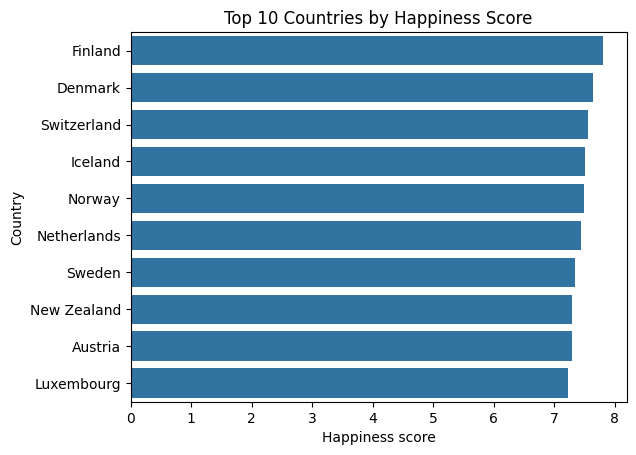

In [ ]:
# Visualize the 10 countries with the highest happiness scores using bar-plot
sns.barplot(data=top10, x="Ladder score", y="Country name")
plt.title("Top 10 Countries by Happiness Score")
plt.xlabel("Happiness score")
plt.ylabel("Country")
plt.show()


### Result
Finland has the highest happiness score in this dataset, followed by Denmark, Switzerland, Iceland and Norway.

### Which regions have higher happiness scores?

In [6]:
# We can calculate the average happiness score for each region.
region_happiness = (analysis_df.groupby("Regional indicator")["Ladder score"] .mean().sort_values(ascending=False))

print(region_happiness)

Regional indicator
North America and ANZ                 7.173525
Western Europe                        6.899219
Latin America and Caribbean           5.981786
Central and Eastern Europe            5.883818
East Asia                             5.714850
Southeast Asia                        5.383367
Commonwealth of Independent States    5.358342
Middle East and North Africa          5.227159
South Asia                            4.475443
Sub-Saharan Africa                    4.383495
Name: Ladder score, dtype: float64


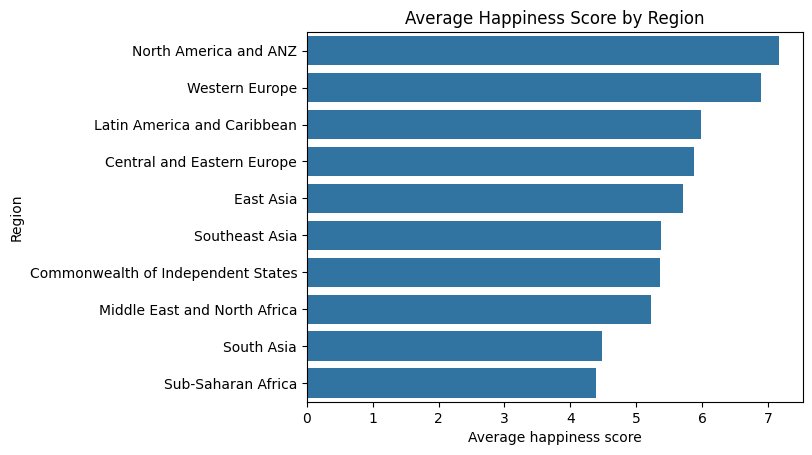

In [7]:
# Visulaize it using bar-plot
sns.barplot(x=region_happiness.values, y=region_happiness.index)

plt.title("Average Happiness Score by Region")
plt.xlabel("Average happiness score")
plt.ylabel("Region")
plt.show()

### Result

North America and ANZ has the highest average happiness score in this dataset.  
Western Europe is second. Sub-Saharan Africa has the lowest average score.

## What variables are most strongly related to happiness?

We can calculate the correlation between `Ladder score` and the main numerical variables.

A correlation close to **+1** means a strong positive relationship.  
A correlation close to **-1** means a strong negative relationship.  
A value close to **0** means little linear relationship.

In [8]:
correlations = analysis_df[
    [
        "Ladder score",
        "Logged GDP per capita",
        "Social support",
        "Healthy life expectancy",
        "Freedom to make life choices",
        "Generosity",
        "Perceptions of corruption"
    ]
].corr()

print(correlations["Ladder score"].sort_values(ascending=False))

Ladder score                    1.000000
Logged GDP per capita           0.775374
Healthy life expectancy         0.770316
Social support                  0.765001
Freedom to make life choices    0.590597
Generosity                      0.069043
Perceptions of corruption      -0.418305
Name: Ladder score, dtype: float64


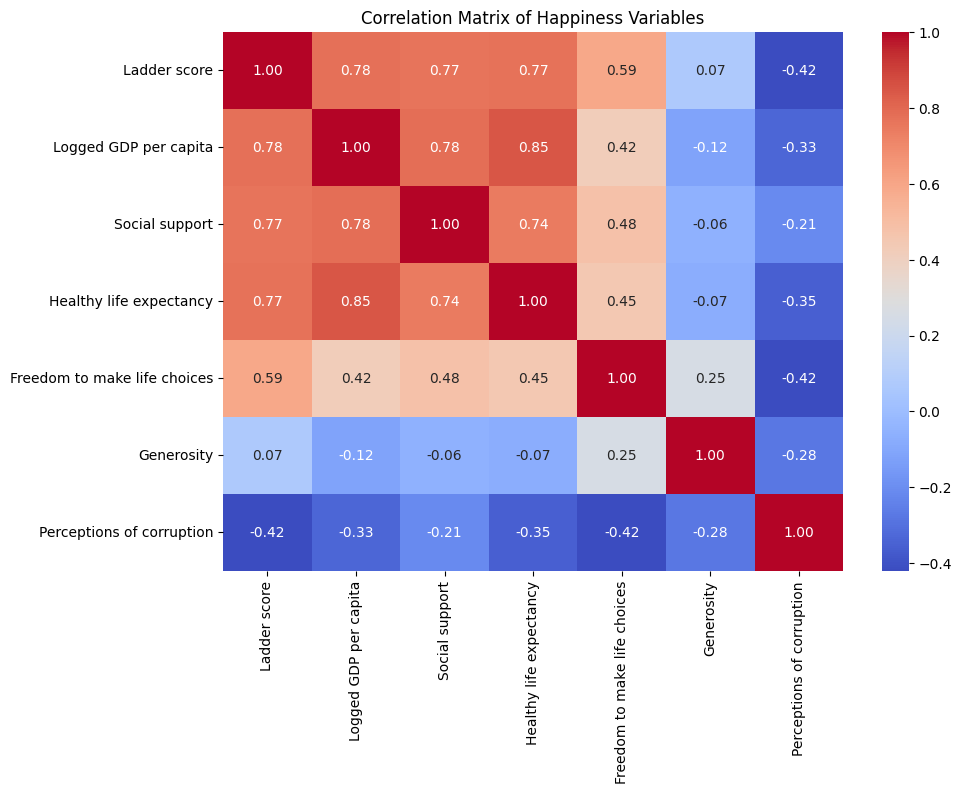

In [9]:
# Visualizwe the Correlation using Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Happiness Variables")
plt.show()


### Main correlation results

The strongest positive relationships with happiness are:

1. **Logged GDP per capita** – about 0.78
2. **Healthy life expectancy** – about 0.77
3. **Social support** – about 0.77
4. **Freedom to make life choices** – about 0.59

Generosity has a very weak relationship with happiness (about 0.07).

Perceptions of corruption has a negative correlation (about -0.42).

### Compare the happiest and least happy countries

In [11]:
bottom10 = analysis_df.nsmallest(10, "Ladder score")

print("10 happiest countries:")
print(top10[["Country name", "Ladder score"]])
print("\n10 least happy countries:")
print(bottom10[["Country name", "Ladder score"]])

10 happiest countries:
  Country name  Ladder score
0      Finland        7.8087
1      Denmark        7.6456
2  Switzerland        7.5599
3      Iceland        7.5045
4       Norway        7.4880
5  Netherlands        7.4489
6       Sweden        7.3535
7  New Zealand        7.2996
8      Austria        7.2942
9   Luxembourg        7.2375

10 least happy countries:
                 Country name  Ladder score
152               Afghanistan        2.5669
151               South Sudan        2.8166
150                  Zimbabwe        3.2992
149                    Rwanda        3.3123
148  Central African Republic        3.4759
147                  Tanzania        3.4762
146                  Botswana        3.4789
145                     Yemen        3.5274
144                    Malawi        3.5380
143                     India        3.5733


<h3><b>Results and summary:</b></h3>

#### Used AI for align my concusions and ideas for further improvements

### Summary

- The dataset contains **153 countries and 20 columns**.
- There are **no missing values** and no duplicate rows in the provided data.
- **Finland** has the highest happiness score in the dataset, with a score of about **7.81**.
- **Afghanistan** has the lowest happiness score, with a score of about **2.57**.
- **North America and ANZ** has the highest average regional happiness score.
- **Logged GDP per capita, healthy life expectancy and social support** have the strongest positive correlations with happiness.
- **Freedom to make life choices** also has a moderately strong positive relationship with happiness.
- **Generosity** has almost no linear correlation with the happiness score in this dataset.
- **Perceptions of corruption** has a moderate negative correlation with happiness.

Overall, the analysis suggests that countries with higher economic conditions, stronger social support and better healthy life expectancy tend to have higher happiness scores. However, these are correlations and do not prove that these factors directly cause higher happiness.

<h3><b>Ideas for further improvements:</b></h3>

- Compare happiness scores across several years to study changes over time.
- Use a regression model to predict the happiness score.
- Investigate the differences between individual regions in more detail.
- Study possible outliers, such as countries whose happiness score is much higher or lower than expected from GDP.
- Compare the results using different correlation methods, such as Spearman correlation.
- Add more years of World Happiness Report data to see whether the relationships stay similar over time.